# Data Loading & Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_excel('/content/uber (1).xlsx')

In [ ]:
df.head()


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2025-09-22,06:39:39,T1984811,Cancelled by Customer,C6701334,Auto,Dilshad Garden,Qutub Minar,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-06-14,11:41:45,T2969701,Cancelled by Customer,C1401223,Auto,Delhi Gate,Chandni Chowk,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-10-10,12:56:23,T6336375,Cancelled by Customer,C7874381,Auto,Laxmi Nagar,IGNOU Road,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-07-30,10:39:07,T1997739,Cancelled by Customer,C3565599,Auto,Seelampur,Kalkaji,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-06-15,08:37:03,T9352835,Cancelled by Customer,C4457487,Auto,Manesar,Old Gurgaon,1.0,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2025-06-29,22:53:26,T3441703,Completed,C3345887,Auto,Udyog Vihar,Kaushambi,NaN,NaN,NaN,NaN,NaN,NaN,300.0,44.72,4.2,4.9,UPI
149996,2025-05-08,16:36:23,T5412815,Completed,C7457601,Auto,Shastri Nagar,Gurgaon Railway Station,NaN,NaN,NaN,NaN,NaN,NaN,328.0,34.35,4.2,4.9,UPI
149997,2025-07-15,17:16:41,T4359237,Completed,C9229149,Auto,Karol Bagh,Udyog Vihar,NaN,NaN,NaN,NaN,NaN,NaN,141.0,25.40,4.2,4.9,UPI
149998,2025-12-08,09:18:33,T5006207,Completed,C8892560,Auto,Karol Bagh,Vaishali,NaN,NaN,NaN,NaN,NaN,NaN,2045.0,37.85,4.2,4.9,UPI
149999,2025-12-24,19:29:32,T2260698,Completed,C6573059,Auto,Khandsa,Botanical Garden,NaN,NaN,NaN,NaN,NaN,NaN,654.0,5.06,4.2,4.9,UPI


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Cancelled Rides by Customer        10500 non-null   float64       
 9   Reason for cancelling by Customer  10500 non-null   object        
 10  Cancelled Rides by D

In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Cancelled Rides by Customer,139500
Reason for cancelling by Customer,139500


In [ ]:
df .drop_duplicates()
df =df.drop_duplicates()
print(f'shape after dropping duplicates:{df.shape}')

shape after dropping duplicates:(150000, 19)


**Transformation**

---

**Check total duplicate rows**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Handling Missing**

In [ ]:
df['Payment Method']=df['Payment Method'].fillna('Not Received')

In [ ]:
df['Customer Rating'] = df.groupby('Vehicle Type')['Customer Rating'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df['Driver Ratings']=df.groupby('Vehicle Type')['Driver Ratings'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df['Ride Distance']= df['Ride Distance'].fillna(0)

In [ ]:
df['Booking Value']=df['Booking Value'].fillna(0)

**Data Type Transformation**

In [ ]:
df. head ()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2025-09-22,06:39:39,T1984811,Cancelled by Customer,C6701334,Auto,Dilshad Garden,Qutub Minar,1.0,Change of plans,0.0,Not Applicable,0.0,Not Applicable,0.0,0.0,4.3,4.4,Not Received
1,2025-06-14,11:41:45,T2969701,Cancelled by Customer,C1401223,Auto,Delhi Gate,Chandni Chowk,1.0,Change of plans,0.0,Not Applicable,0.0,Not Applicable,0.0,0.0,4.3,4.4,Not Received
2,2025-10-10,12:56:23,T6336375,Cancelled by Customer,C7874381,Auto,Laxmi Nagar,IGNOU Road,1.0,Change of plans,0.0,Not Applicable,0.0,Not Applicable,0.0,0.0,4.3,4.4,Not Received
3,2025-07-30,10:39:07,T1997739,Cancelled by Customer,C3565599,Auto,Seelampur,Kalkaji,1.0,Change of plans,0.0,Not Applicable,0.0,Not Applicable,0.0,0.0,4.3,4.4,Not Received
4,2025-06-15,08:37:03,T9352835,Cancelled by Customer,C4457487,Auto,Manesar,Old Gurgaon,1.0,Change of plans,0.0,Not Applicable,0.0,Not Applicable,0.0,0.0,4.3,4.4,Not Received


#Data Type Conversion

In [ ]:

df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].astype(int)

In [ ]:
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].astype(int)

In [ ]:
df['Incomplete Rides'] = df['Incomplete Rides'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Cancelled Rides by Customer        150000 non-null  int64         
 9   Reason for cancelling by Customer  150000 non-null  object        
 10  Cancelled Rides by D

**EDA**

/tmp/ipykernel_1870/1066985338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Booking Status', palette='viridis')


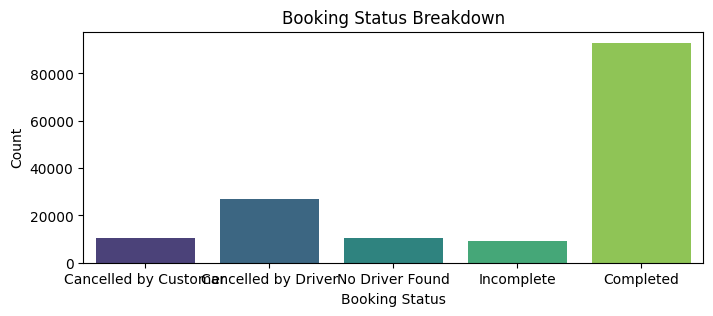

In [ ]:
# Visualize booking status proportion
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='Booking Status', palette='viridis')
plt.title('Booking Status Breakdown')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2419/101059768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Vehicle Type', order=df['Vehicle Type'].value_counts().index, palette='magma')


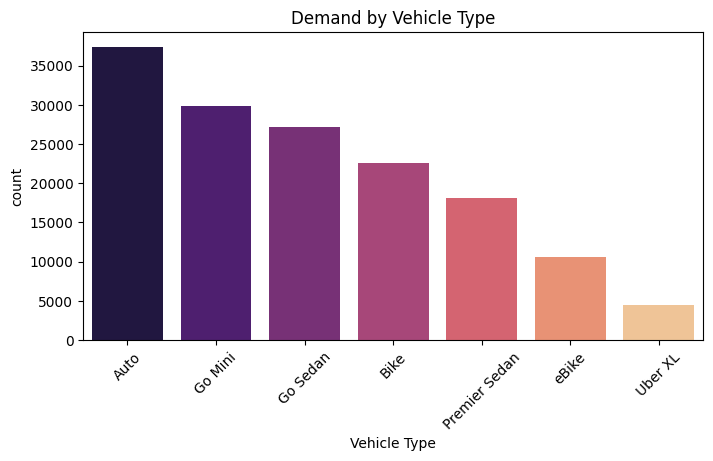

In [ ]:
# Demand by Vehicle Type
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Vehicle Type', order=df['Vehicle Type'].value_counts().index, palette='magma')
plt.title('Demand by Vehicle Type')
plt.xticks(rotation=45)
plt.show()

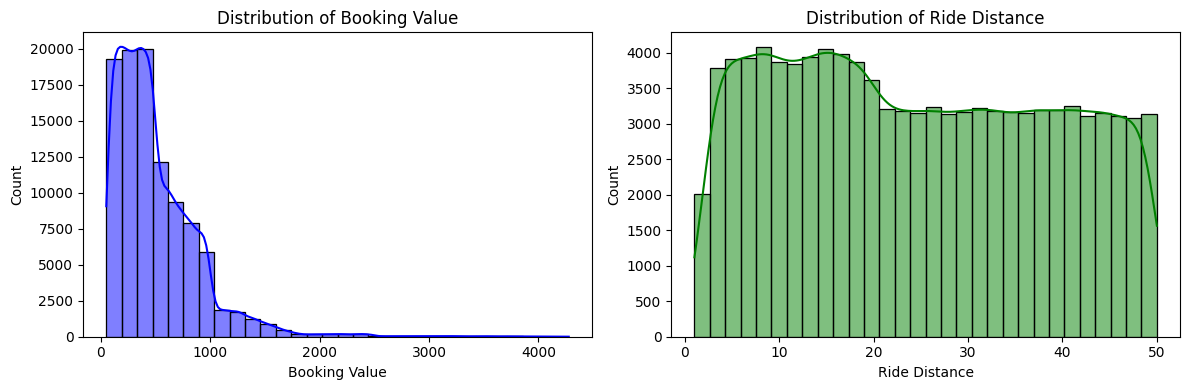

In [ ]:
# Distribution of Ride Distance and Booking Value
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df['Booking Value'] > 0]['Booking Value'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Booking Value')

sns.histplot(df[df['Ride Distance'] > 0]['Ride Distance'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Ride Distance')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2419/3969908378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Booking Value'] > 0], x='Vehicle Type', y='Booking Value', palette='Set2')


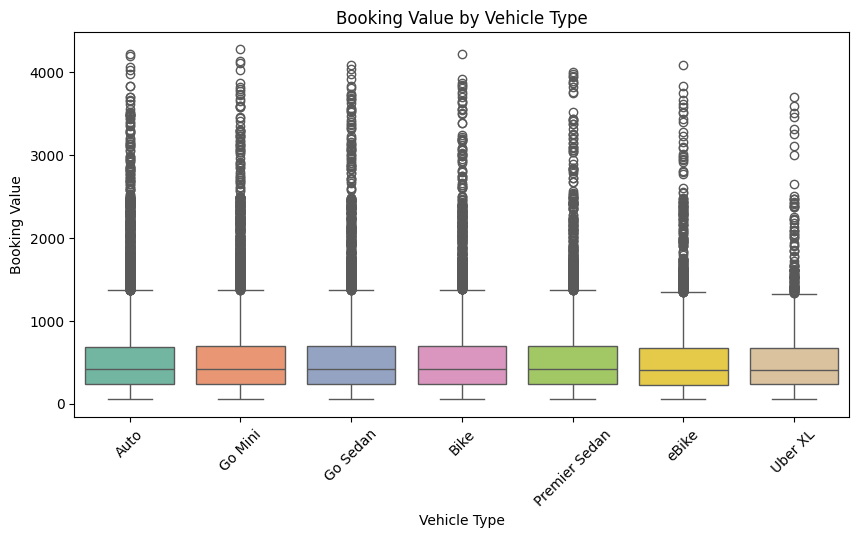

In [ ]:
# Booking Value distribution across Vehicle Types
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['Booking Value'] > 0], x='Vehicle Type', y='Booking Value', palette='Set2')
plt.title('Booking Value by Vehicle Type')
plt.xticks(rotation=45)
plt.show()

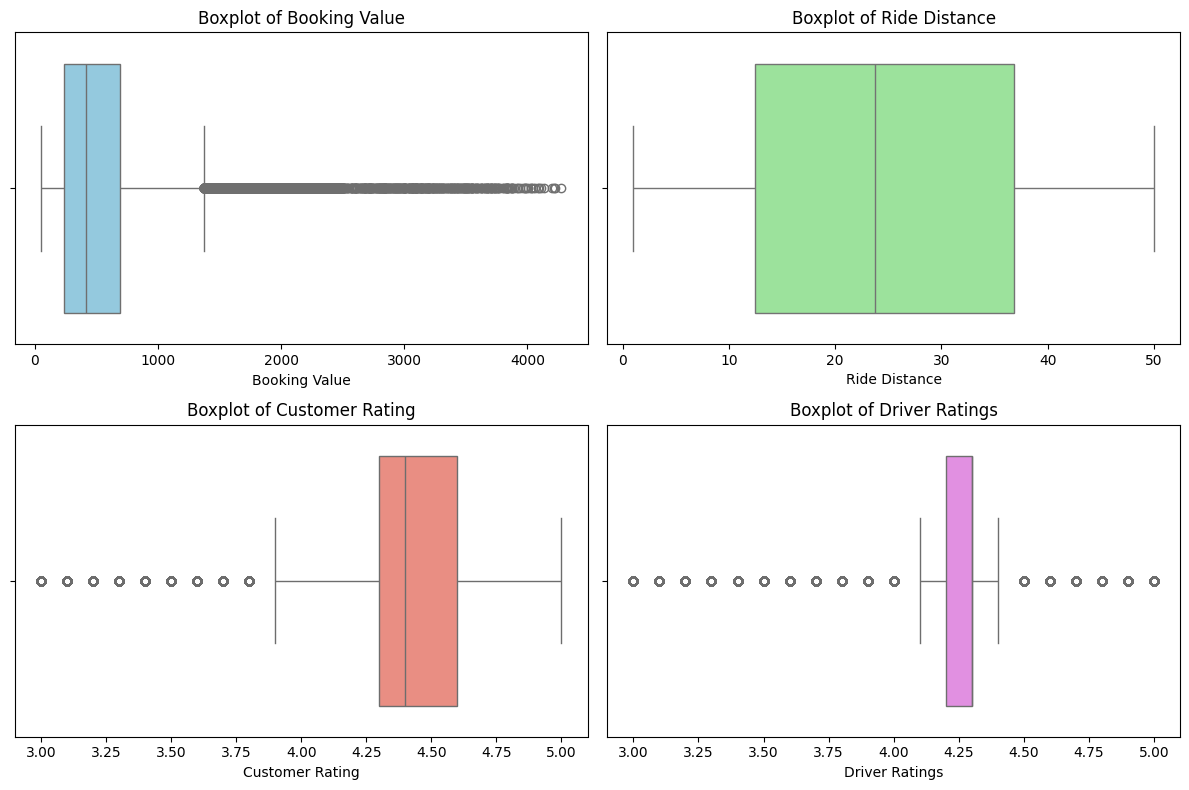

In [ ]:
# Create subplots for numerical feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Booking Value Boxplot
sns.boxplot(data=df[df['Booking Value'] > 0], x='Booking Value', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Boxplot of Booking Value')

# 2. Ride Distance Boxplot
sns.boxplot(data=df[df['Ride Distance'] > 0], x='Ride Distance', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Boxplot of Ride Distance')

# 3. Customer Rating Boxplot
sns.boxplot(data=df, x='Customer Rating', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Boxplot of Customer Rating')

# 4. Driver Ratings Boxplot
sns.boxplot(data=df, x='Driver Ratings', ax=axes[1, 1], color='violet')
axes[1, 1].set_title('Boxplot of Driver Ratings')

plt.tight_layout()
plt.show()

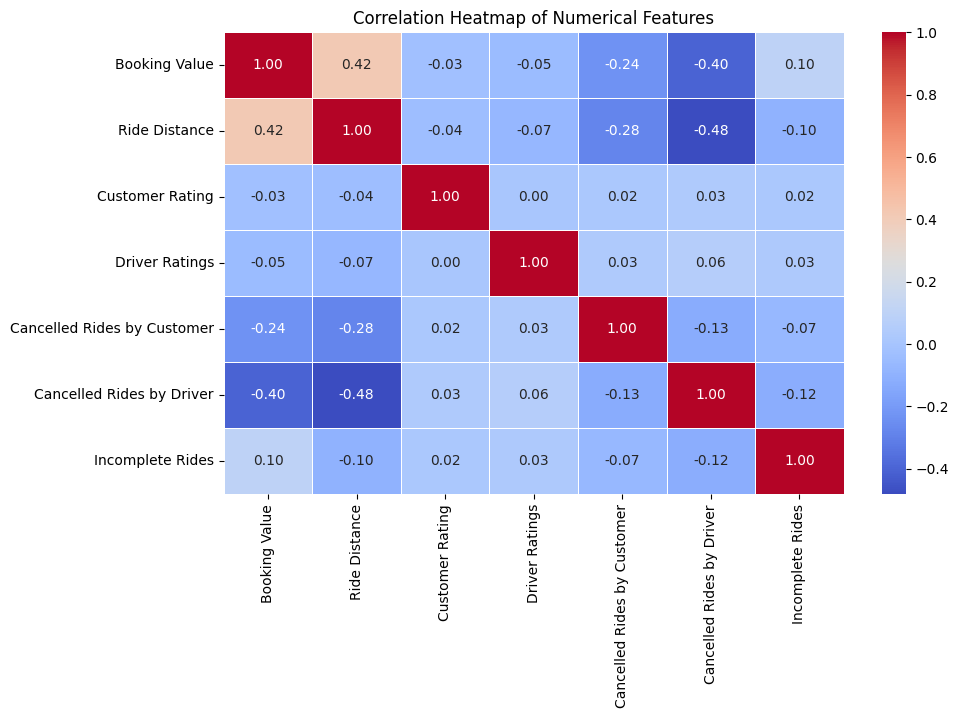

In [ ]:
# Select numerical columns for correlation analysis
num_cols = ['Booking Value', 'Ride Distance', 'Customer Rating', 'Driver Ratings',
            'Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides']

plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

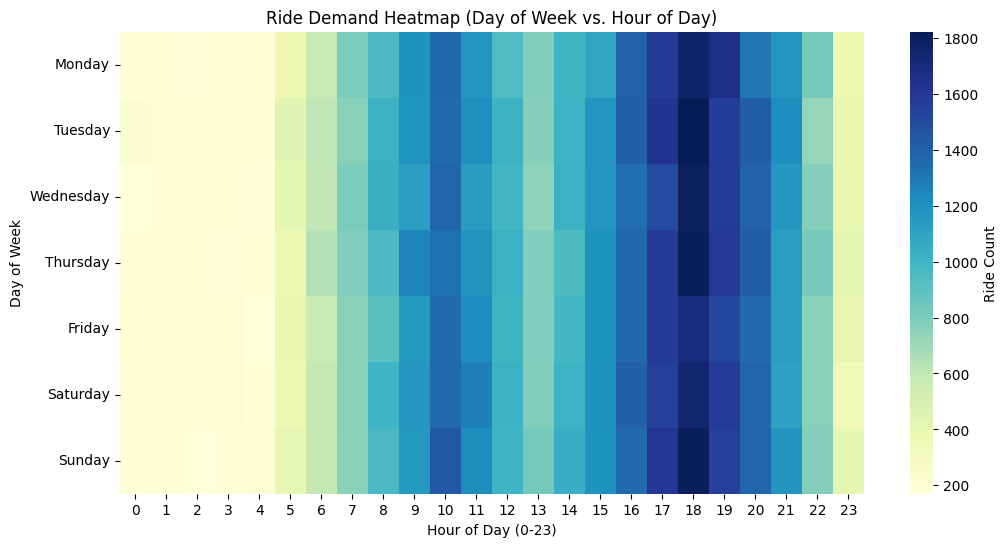

In [ ]:
# Extract Day of Week name
df['Day_of_Week'] = df['Date_Time'].dt.day_name()

# Pivot table for Day vs. Hour demand matrix
pivot_table = df.pivot_table(index='Day_of_Week', columns='Hour', values='Booking ID', aggfunc='count')

# Order days logically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(days_order)

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Ride Count'})
plt.title('Ride Demand Heatmap (Day of Week vs. Hour of Day)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of Week')
plt.show()